In [2]:
import sqlite3
import pandas as pd
import sqlalchemy
from sqlalchemy import create_engine

print(sqlite3.version)
print(sqlalchemy.__version__)

2.6.0
2.0.49


/tmp/ipykernel_11343/1755424524.py:6: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  print(sqlite3.version)


In [3]:
engine = create_engine("sqlite:///amr_watch.db")
print("Engine created!")
print(type(engine))

Engine created!
<class 'sqlalchemy.engine.base.Engine'>


In [4]:
df = pd.read_csv ("/content/drive/MyDrive/antibiotic_resistance_tracking.csv")

In [5]:
df.head(10)
df.shape
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        2199 non-null   object
 1   Age               2200 non-null   int64 
 2   Gender            2200 non-null   object
 3   Specimen_Type     2200 non-null   object
 4   Amoxicillin       2200 non-null   object
 5   Ciprofloxacin     2200 non-null   object
 6   Meropenem         2200 non-null   object
 7   Vancomycin        2200 non-null   object
 8   Colistin          2200 non-null   object
 9   Test_Method       2200 non-null   object
 10  Resistance_Genes  1763 non-null   object
 11  Outcome           2200 non-null   object
dtypes: int64(1), object(11)
memory usage: 206.4+ KB


In [6]:
df.head(10)

,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered
2,P0003,13,Female,Urine,Intermediate,Sensitive,Resistant,Intermediate,Resistant,MIC,OXA-48,ICU
3,P0004,4,Female,Sputum,Intermediate,Resistant,Sensitive,Intermediate,Intermediate,Automated System,OXA-48,ICU
4,P0005,51,Male,Urine,Resistant,Sensitive,Resistant,Intermediate,Intermediate,Automated System,NaN,ICU
5,P0006,10,Male,Sputum,Resistant,Intermediate,Sensitive,Intermediate,Intermediate,Disc Diffusion,VIM,Deceased
6,P0007,45,Female,Wound swab,Intermediate,Resistant,Resistant,Sensitive,Intermediate,Automated System,OXA-48,ICU
7,P0008,75,Male,Sputum,Resistant,Resistant,Resistant,Sensitive,Sensitive,Automated System,KPC,Recovered
8,P0009,46,Male,Blood,Resistant,Intermediate,Intermediate,Resistant,Resistant,Automated System,NDM-1,ICU
9,P0010,90,Female,Sputum,Intermediate,Intermediate,Sensitive,Resistant,Sensitive,Automated System,VIM,Recovered


In [7]:
df = df.dropna(subset=["Patient_ID"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2199 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        2199 non-null   object
 1   Age               2199 non-null   int64 
 2   Gender            2199 non-null   object
 3   Specimen_Type     2199 non-null   object
 4   Amoxicillin       2199 non-null   object
 5   Ciprofloxacin     2199 non-null   object
 6   Meropenem         2199 non-null   object
 7   Vancomycin        2199 non-null   object
 8   Colistin          2199 non-null   object
 9   Test_Method       2199 non-null   object
 10  Resistance_Genes  1762 non-null   object
 11  Outcome           2199 non-null   object
dtypes: int64(1), object(11)
memory usage: 223.3+ KB


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2199 entries, 0 to 2199
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        2199 non-null   object
 1   Age               2199 non-null   int64 
 2   Gender            2199 non-null   object
 3   Specimen_Type     2199 non-null   object
 4   Amoxicillin       2199 non-null   object
 5   Ciprofloxacin     2199 non-null   object
 6   Meropenem         2199 non-null   object
 7   Vancomycin        2199 non-null   object
 8   Colistin          2199 non-null   object
 9   Test_Method       2199 non-null   object
 10  Resistance_Genes  1762 non-null   object
 11  Outcome           2199 non-null   object
dtypes: int64(1), object(11)
memory usage: 223.3+ KB


In [9]:
df["Resistance_Genes"] = df["Resistance_Genes"].fillna("Not_tested")

In [10]:
df.head(20)

,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered
2,P0003,13,Female,Urine,Intermediate,Sensitive,Resistant,Intermediate,Resistant,MIC,OXA-48,ICU
3,P0004,4,Female,Sputum,Intermediate,Resistant,Sensitive,Intermediate,Intermediate,Automated System,OXA-48,ICU
4,P0005,51,Male,Urine,Resistant,Sensitive,Resistant,Intermediate,Intermediate,Automated System,Not_tested,ICU
5,P0006,10,Male,Sputum,Resistant,Intermediate,Sensitive,Intermediate,Intermediate,Disc Diffusion,VIM,Deceased
6,P0007,45,Female,Wound swab,Intermediate,Resistant,Resistant,Sensitive,Intermediate,Automated System,OXA-48,ICU
7,P0008,75,Male,Sputum,Resistant,Resistant,Resistant,Sensitive,Sensitive,Automated System,KPC,Recovered
8,P0009,46,Male,Blood,Resistant,Intermediate,Intermediate,Resistant,Resistant,Automated System,NDM-1,ICU
9,P0010,90,Female,Sputum,Intermediate,Intermediate,Sensitive,Resistant,Sensitive,Automated System,VIM,Recovered


In [11]:
 df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Specimen_Type,0
Amoxicillin,0
Ciprofloxacin,0
Meropenem,0
Vancomycin,0
Colistin,0
Test_Method,0


In [12]:
df.head()

,Patient_ID,Age,Gender,Specimen_Type,Amoxicillin,Ciprofloxacin,Meropenem,Vancomycin,Colistin,Test_Method,Resistance_Genes,Outcome
0,P0001,36,Female,Blood,Intermediate,Sensitive,Intermediate,Intermediate,Intermediate,Automated System,KPC,ICU
1,P0002,59,Female,Blood,Intermediate,Resistant,Intermediate,Sensitive,Intermediate,MIC,KPC,Recovered
2,P0003,13,Female,Urine,Intermediate,Sensitive,Resistant,Intermediate,Resistant,MIC,OXA-48,ICU
3,P0004,4,Female,Sputum,Intermediate,Resistant,Sensitive,Intermediate,Intermediate,Automated System,OXA-48,ICU
4,P0005,51,Male,Urine,Resistant,Sensitive,Resistant,Intermediate,Intermediate,Automated System,Not_tested,ICU


In [13]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///amr_watch.db")

df.to_sql("lab_results", engine, if_exists="replace", index=False)

print("Data written to database successfully!")

Data written to database successfully!


In [14]:

query = "SELECT * FROM lab_results LIMIT 5"
result = pd.read_sql(query, engine)
print(result)

  Patient_ID  Age  Gender Specimen_Type   Amoxicillin Ciprofloxacin  \
0      P0001   36  Female         Blood  Intermediate     Sensitive   
1      P0002   59  Female         Blood  Intermediate     Resistant   
2      P0003   13  Female         Urine  Intermediate     Sensitive   
3      P0004    4  Female        Sputum  Intermediate     Resistant   
4      P0005   51    Male         Urine     Resistant     Sensitive   

      Meropenem    Vancomycin      Colistin       Test_Method  \
0  Intermediate  Intermediate  Intermediate  Automated System   
1  Intermediate     Sensitive  Intermediate               MIC   
2     Resistant  Intermediate     Resistant               MIC   
3     Sensitive  Intermediate  Intermediate  Automated System   
4     Resistant  Intermediate  Intermediate  Automated System   

  Resistance_Genes    Outcome  
0              KPC        ICU  
1              KPC  Recovered  
2           OXA-48        ICU  
3           OXA-48        ICU  
4       Not_tested    

In [15]:
query = """SELECT Amoxicillin, COUNT(*) as count
FROM lab_results
GROUP BY Amoxicillin"""

results = pd.read_sql (query, engine)

print(results)

    Amoxicillin  count
0  Intermediate    743
1     Resistant    730
2     Sensitive    726


In [16]:
query = """SELECT Specimen_Type, COUNT(*) as resistant_count
FROM lab_results
WHERE Amoxicillin = 'Resistant'
GROUP BY Specimen_Type
ORDER BY resistant_count DESC
LIMIT 1"""
results = pd.read_sql (query, engine)
print(results)

  Specimen_Type  resistant_count
0    Wound swab              156


In [17]:
query = """SELECT Resistance_Genes, COUNT(*) AS count FROM lab_results
           WHERE Resistance_Genes NOT IN ("Not_tested")
           GROUP BY Resistance_Genes
           ORDER BY count DESC
           LIMIT 1"""
results = pd.read_sql (query, engine)
print(results)

  Resistance_Genes  count
0              VIM    463


In [18]:
outcomes_summary = df.groupby(["Outcome", "Specimen_Type"]).size().reset_index(name="count")
outcomes_summary.to_sql("outcomes", engine, if_exists="replace", index=False)
print("Outcomes table created!")

Outcomes table created!


In [19]:
print(outcomes_summary.head(10))
print(outcomes_summary.shape)

    Outcome Specimen_Type  count
0  Deceased         Blood    136
1  Deceased        Sputum    148
2  Deceased         Stool    125
3  Deceased         Urine    144
4  Deceased    Wound swab    133
5       ICU         Blood    159
6       ICU        Sputum    156
7       ICU         Stool    143
8       ICU         Urine    157
9       ICU    Wound swab    159
(15, 3)


In [20]:
## which specimen type had the highest resistance to Meropenem, and how many total deceased cases did that specimen type have?
query = """SELECT o.Outcome, count(*) as Resistant_count, lr.Resistance_Genes, lr.Meropenem, lr.Specimen_Type
           FROM lab_results lr
           JOIN outcomes o on lr.Specimen_Type = o.Specimen_Type
                          AND lr.Outcome = o.Outcome
           WHERE o.Outcome = "Deceased"
           AND lr.Meropenem = "Resistant"
           GROUP BY lr.Specimen_Type
           ORDER BY Resistant_count DESC
           LIMIT 1"""

results = pd.read_sql (query, engine)
print(results)

    Outcome  Resistant_count Resistance_Genes  Meropenem Specimen_Type
0  Deceased               51              VIM  Resistant         Urine


In [21]:
patient_df = df[["Patient_ID", "Age", "Gender", "Outcome"]]
patient_df.to_sql("Patients", engine, if_exists="replace", index=False)
lab_resultsdf = df[["Patient_ID", "Specimen_Type", "Test_Method", "Amoxicillin", "Ciprofloxacin",
                     "Meropenem", "Vancomycin", "Colistin", "Resistance_Genes"]]
lab_resultsdf.to_sql("lab_results", engine, if_exists="replace", index=False)
gene_counts = df.groupby("Resistance_Genes").size().reset_index(name="count")
most_common_outcome = df.groupby("Resistance_Genes")["Outcome"].agg(lambda x: x.mode()[0])
Resistance_summary_df = pd.merge(gene_counts, most_common_outcome, on="Resistance_Genes", how="left")
Resistance_summary_df.to_sql("Resistance_summary", engine, if_exists="replace", index=False)

5

In [22]:
most_common_outcome = most_common_outcome.reset_index()
most_common_outcome.columns = ["Resistance_Genes", "most_common_outcome"]

In [23]:
from sqlalchemy import inspect
inspector = inspect(engine)
print(inspector.get_table_names())

['Patients', 'Resistance_summary', 'lab_results', 'outcomes']


In [24]:
query = """SELECT * FROM Patients"""
results = pd.read_sql (query, engine)
print(results)

     Patient_ID  Age  Gender    Outcome
0         P0001   36  Female        ICU
1         P0002   59  Female  Recovered
2         P0003   13  Female        ICU
3         P0004    4  Female        ICU
4         P0005   51    Male        ICU
...         ...  ...     ...        ...
2194      P0996   78    Male        ICU
2195      P0997   85    Male        ICU
2196      P0998   32    Male  Recovered
2197      P0999    2    Male  Recovered
2198      P1000   19  Female        ICU

[2199 rows x 4 columns]


In [36]:
## Which resistance gene is most associated with deceased patients?
query = """SELECT Resistance_Genes, COUNT (*) as deceased_count
           FROM lab_results lr
           JOIN Patients p on lr.Patient_ID = p.Patient_ID
           WHERE Outcome = "Deceased"
           GROUP BY lr.Resistance_Genes
           ORDER BY deceased_count DESC
           LIMIT 1"""
results = pd.read_sql(query, engine)
print(results)

  Resistance_Genes  deceased_count
0              VIM             167


In [26]:
print(df["Outcome"].value_counts())

Outcome
ICU          774
Recovered    739
Deceased     686
Name: count, dtype: int64


In [27]:
## What is the resistance rate for Meropenem by specimen type?
query = """SELECT Specimen_Type,
           CAST(SUM(CASE WHEN Meropenem = "Resistant" THEN 1 ELSE 0 END)AS REAL) * 100 /
           COUNT (*) AS Meropenem_count
            FROM lab_results
            GROUP BY Specimen_Type"""
results = pd.read_sql(query, engine)
print(results)


  Specimen_Type  Meropenem_count
0         Blood        36.383929
1        Sputum        30.803571
2         Stool        36.255924
3         Urine        36.258661
4    Wound swab        31.919643


In [28]:
## Which test method detects the most resistant cases across all antibiotics?

query = """SELECT
    Test_Method,
    SUM(CASE WHEN Amoxicillin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Ciprofloxacin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Meropenem = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Vancomycin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Colistin = 'Resistant' THEN 1 ELSE 0 END) AS Total_Resistant_Cases
FROM
    lab_results
GROUP BY
    Test_Method
ORDER BY
    Total_Resistant_Cases DESC
LIMIT 1;"""
results = pd.read_sql(query, engine)
print(results)

      Test_Method  Total_Resistant_Cases
0  Disc Diffusion                   1225


In [32]:
## Are male or female patients more likely to have a Deceased outcome?
query = """SELECT GENDER,
           COUNT(CASE WHEN Outcome = "Deceased" THEN 1 END) AS deceased_count,
           COUNT(Patient_ID) AS total_patients_per_gender,
           ROUND(CAST(COUNT(CASE WHEN Outcome = "Deceased" THEN 1 END) AS REAL) * 100.0 / COUNT(Patient_ID), 2) AS mortality_rate
           FROM Patients
           GROUP BY Gender
           ORDER BY mortality_rate DESC"""
results = pd.read_sql(query, engine)
print(results)

   Gender  deceased_count  total_patients_per_gender  mortality_rate
0  Female             356                       1110           32.07
1    Male             330                       1089           30.30


In [35]:
query = """SELECT
         ROUND(COUNT(CASE WHEN Amoxicillin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Amoxicillin), 0), 2) AS Amoxicillin_rate,

         ROUND(COUNT(CASE WHEN Vancomycin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Vancomycin), 0), 2) AS Vancomycin_rate,

          ROUND(COUNT(CASE WHEN Colistin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Colistin), 0), 2) AS Colistin_rate,

          ROUND(COUNT(CASE WHEN Ciprofloxacin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Ciprofloxacin), 0), 2) AS Ciprofloxacin_rate,

          ROUND(COUNT(CASE WHEN Meropenem = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Meropenem), 0), 2) AS Meropenem_rate

          FROM lab_results"""

results = pd.read_sql(query, engine)
print(results)

   Amoxicillin_rate  Vancomycin_rate  Colistin_rate  Ciprofloxacin_rate  \
0              33.2            32.61          31.83               32.65   

   Meropenem_rate  
0           34.29  


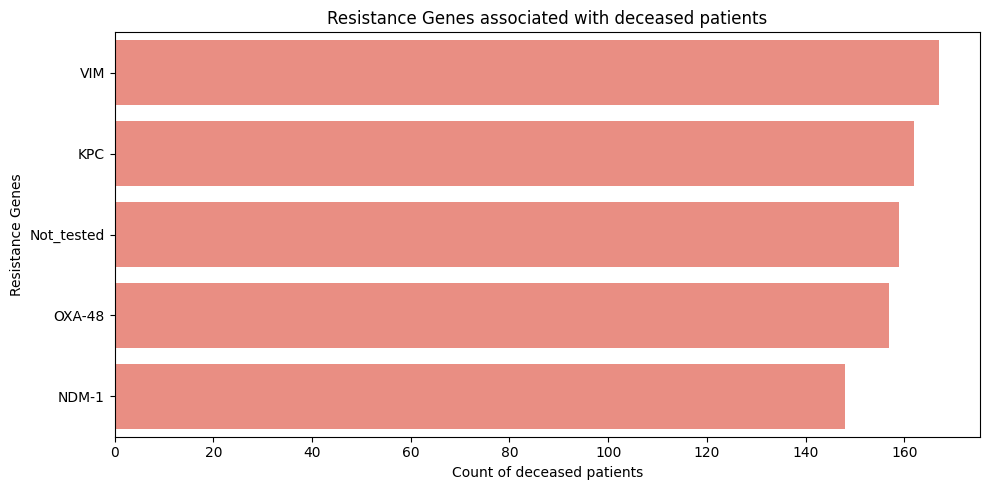

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query = """SELECT Resistance_Genes, COUNT (*) as deceased_count
           FROM lab_results lr
           JOIN Patients p on lr.Patient_ID = p.Patient_ID
           WHERE Outcome = "Deceased"
           GROUP BY lr.Resistance_Genes
           ORDER BY deceased_count DESC"""

df = pd.read_sql(query, engine)

plt.figure(figsize = (10,5))
sns.barplot(data=df, x = "deceased_count", y="Resistance_Genes", color = "salmon")
plt.title("Resistance Genes associated with deceased patients")
plt.ylabel("Resistance Genes")
plt.xlabel("Count of deceased patients")
plt.tight_layout()
plt.show()

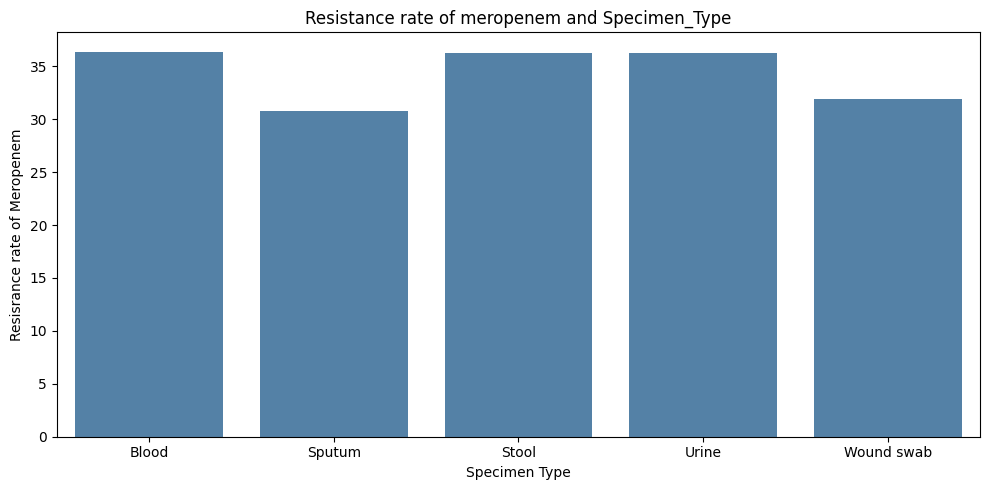

In [46]:
query = """SELECT Specimen_Type,
           CAST(SUM(CASE WHEN Meropenem = "Resistant" THEN 1 ELSE 0 END)AS REAL) * 100 /
           COUNT (*) AS Meropenem_count
            FROM lab_results
            GROUP BY Specimen_Type"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(10,5))
sns.barplot(data=df, x = "Specimen_Type", y="Meropenem_count", color = "steelblue")
plt.title("Resistance rate of meropenem and Specimen_Type")
plt.xlabel("Specimen Type")
plt.ylabel("Resisrance rate of Meropenem")
plt.tight_layout()
plt.show()

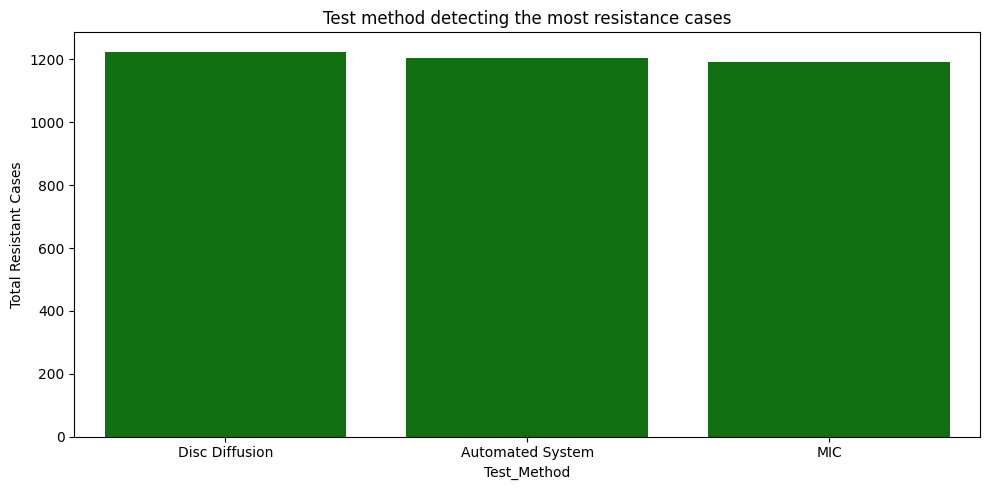

In [60]:
 query = """SELECT
    Test_Method,
    SUM(CASE WHEN Amoxicillin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Ciprofloxacin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Meropenem = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Vancomycin = 'Resistant' THEN 1 ELSE 0 END +
        CASE WHEN Colistin = 'Resistant' THEN 1 ELSE 0 END) AS Total_Resistant_Cases
FROM
    lab_results
GROUP BY
    Test_Method
ORDER BY
    Total_Resistant_Cases DESC"""

 df = pd.read_sql(query, engine)

 plt.figure(figsize=(10,5))
 sns.barplot(data=df, y= "Total_Resistant_Cases", x= "Test_Method", color = "green")
 plt.title("Test method detecting the most resistance cases")
 plt.ylabel("Total Resistant Cases")
 plt.xlabel("Test_Method")
 plt.tight_layout()
 plt.show()

           Antibiotic  Resistance_Rate
0    Amoxicillin_rate            33.20
1     Vancomycin_rate            32.61
2       Colistin_rate            31.83
3  Ciprofloxacin_rate            32.65
4      Meropenem_rate            34.29


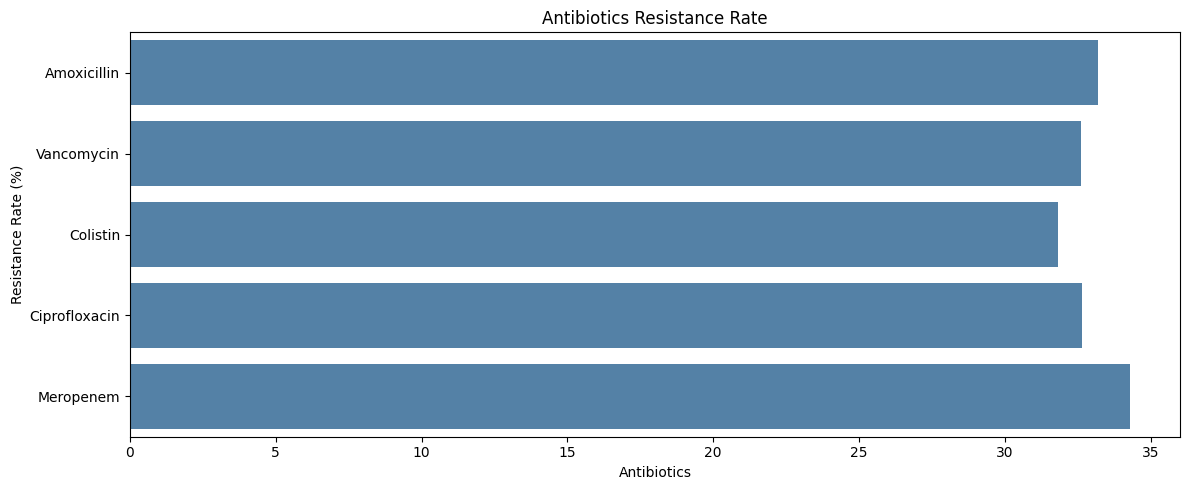

In [62]:
query = """SELECT
         ROUND(COUNT(CASE WHEN Amoxicillin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Amoxicillin), 0), 2) AS Amoxicillin_rate,
         ROUND(COUNT(CASE WHEN Vancomycin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Vancomycin), 0), 2) AS Vancomycin_rate,
          ROUND(COUNT(CASE WHEN Colistin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Colistin), 0), 2) AS Colistin_rate,
          ROUND(COUNT(CASE WHEN Ciprofloxacin = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Ciprofloxacin), 0), 2) AS Ciprofloxacin_rate,
          ROUND(COUNT(CASE WHEN Meropenem = 'Resistant' THEN 1 END) * 100.0 /
          NULLIF(COUNT(Meropenem), 0), 2) AS Meropenem_rate
          FROM lab_results"""

results = pd.read_sql(query, engine)

antibiotic_rates = results.T.reset_index()
antibiotic_rates.columns = ["Antibiotic", "Resistance_Rate"]
print(antibiotic_rates)
antibiotic_rates["Antibiotic"] = antibiotic_rates["Antibiotic"].str.replace("_rate", "")

plt.figure(figsize=(12,5))
sns.barplot(data=antibiotic_rates, y="Antibiotic", x="Resistance_Rate", color="steelblue")
plt.title("Antibiotics Resistance Rate")
plt.xlabel("Antibiotics")
plt.ylabel("Resistance Rate (%)")
plt.tight_layout()
plt.show()


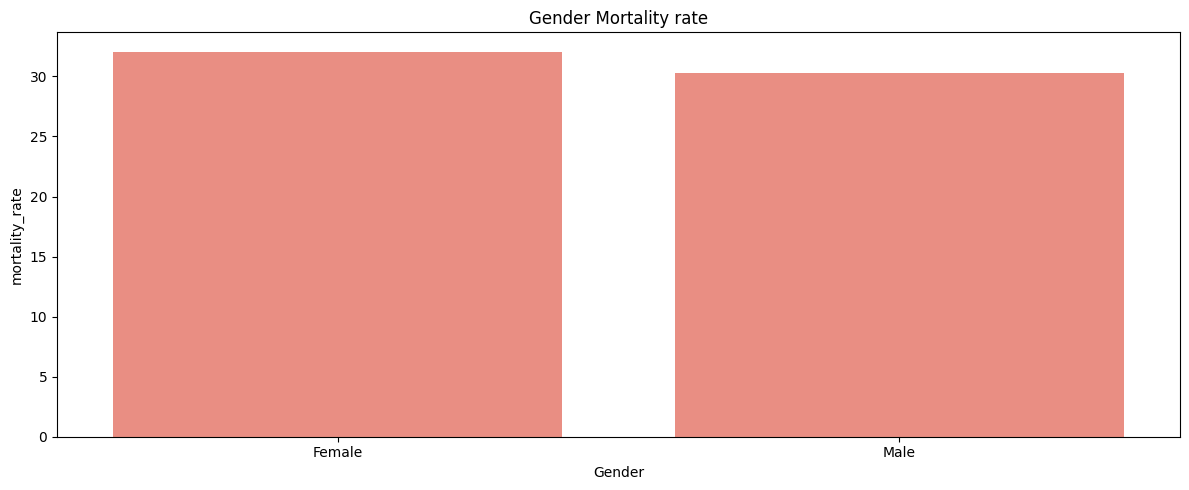

In [61]:
query = """SELECT GENDER,
           COUNT(CASE WHEN Outcome = "Deceased" THEN 1 END) AS deceased_count,
           COUNT(Patient_ID) AS total_patients_per_gender,
           ROUND(CAST(COUNT(CASE WHEN Outcome = "Deceased" THEN 1 END) AS REAL) * 100.0 / COUNT(Patient_ID), 2) AS mortality_rate
           FROM Patients
           GROUP BY Gender
           ORDER BY mortality_rate DESC"""
df = pd.read_sql(query, engine)

plt.figure(figsize=(12,5))
sns.barplot(data=df, x="Gender", y="mortality_rate", color="salmon")
plt.title("Gender Mortality rate")
plt.xlabel("Gender")
plt.ylabel("mortality_rate")
plt.tight_layout()
plt.show()

1. Patient Demographics and Outcomes
The dataset contains 2199 patient records, with 1110 female and 1089 male patients. The overall outcomes distribution is: 774 ICU, 739 Recovered, and 686 Deceased patients.

Gender and Mortality Rate (Figure: 'Gender Mortality rate'): While the raw count of deceased females is slightly higher (356 vs. 330 for males), the mortality rate suggests a marginal difference: 32.07% for females and 30.30% for males. This indicates that gender might not be a primary determinant of deceased outcome in this dataset, or other factors play a more significant role.

2. Antibiotic Resistance Patterns
Overall Antibiotic Resistance Rates (Figure: 'Antibiotics Resistance Rate'): Among the tested antibiotics, Meropenem exhibits the highest resistance rate at 34.29%. It is followed by Amoxicillin (33.20%), Ciprofloxacin (32.65%), Vancomycin (32.61%), and Colistin (31.83%). Considering Meropenem is a 3rd line antibiotic, this is an alarming issue. Finally, The resistance rates across all antibiotics are relatively similar, hovering around one-third of the tested cases.
3. Resistance Genes Analysis
Resistance Genes in Deceased Patients (Figure: 'Resistance Genes associated with deceased patients'): The VIM gene is most frequently associated with deceased patients, appearing in 167 cases. This suggests a potential link between the presence of the VIM gene and severe patient outcomes.
4. Specimen Type and Test Method
Meropenem Resistance by Specimen Type (Figure: 'Resistance rate of Meropenem by Specimen Type'): Blood, Stool, and Urine specimens show the highest Meropenem resistance rates (approximately 36%), slightly higher than Sputum and Wound Swab specimens (around 31-32%). This indicates that Meropenem resistance might be slightly more prevalent in bloodstream, gastrointestinal, and urinary tract infections.

Test Method Effectiveness (Figure: 'Test method detecting the most resistance cases'): The 'Disc Diffusion' method detected the highest number of total resistant cases across all antibiotics (1225). This suggests that Disc Diffusion is a frequently used or highly effective method for identifying antibiotic resistance in this dataset, or it may be applied to a larger volume of samples.

5. Conclusion
This analysis reveals that VIM is the most common resistance gene associated with deceased patients. Meropenem shows the highest overall resistance rate among the tested antibiotics, with resistance being slightly more pronounced in Blood, Stool, and Urine specimens. The Disc Diffusion test method appears to be a key tool in detecting a significant number of resistance cases. These findings can inform clinical decisions and further research into antibiotic resistance management.

Based on these findings we recommend:
 (1) urgent review of carbapenem prescribing protocols given 34.29% Meropenem resistance;
 (2) enhanced VIM surveillance in deceased patient cohorts;
  (3) investigation into bloodstream infection management protocols given highest Meropenem resistance in blood specimens